# 量子开放系统课程汇报--张量网络：第一部分
## 奇异值分解的两种理解

$$
A = U\Sigma V^\top = \sum_{i=1}^{r}\sigma_i u_i v_i^\top,
\qquad
\sigma_1 \ge \sigma_2 \ge \cdots \ge 0
$$

奇异值分解可以有的两种理解:

1. 几何理解：$V^\top \to \Sigma \to U$
2. 近似理解：保留前 $k$ 个奇异值得到最优 rank-$k$ 近似

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd
from PIL import Image
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
    "DejaVu Sans",
]

## SVD 分解

$$
A_{m\times n}=U_{m\times m}\,\Sigma_{m\times n}\,V^\dagger_{n\times n},
\qquad
UU^\dagger=I_{m\times m},
\qquad
VV^\dagger=I_{n\times n}
$$

$$
\Sigma_{m\times n}\ \text{为对角阵，对角元称奇异值}
$$

1. 奇异值为非负实数；
2. 奇异值按降序排列。

$$
\Sigma=
\begin{pmatrix}
\sigma_1 & & & \\
& \sigma_2 & & \\
& & \ddots & \\
& & & \sigma_r
\end{pmatrix}
$$

$$
\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0,
\qquad
r=\operatorname{rank}(A)
$$

当 $r<\min(m,n)$ 时，其余奇异值为 $0$。

## 例：一个 $2\times 3$ 矩阵

取

$$
A=
\begin{bmatrix}
3 & 2 & 2\\
2 & 3 & -2
\end{bmatrix}
$$

reduced SVD 为

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{2\times 2},\quad
\Sigma\in\mathbb{R}^{2\times 2},\quad
V^\top\in\mathbb{R}^{2\times 3}
$$

In [2]:
A = np.array([
    [3.0, 2.0,  2.0],
    [2.0, 3.0, -2.0],
])

U_A, s_A, Vt_A = np.linalg.svd(A, full_matrices=False)
Sigma_A = np.diag(s_A)

print("A =")
print(A)
print("\nU shape =", U_A.shape)
print("Sigma shape =", Sigma_A.shape)
print("V^T shape =", Vt_A.shape)
print("\n奇异值 =", s_A)
print("\n重构误差 ||A-UΣV^T|| =", np.linalg.norm(A - U_A @ Sigma_A @ Vt_A))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]]

U shape = (2, 2)
Sigma shape = (2, 2)
V^T shape = (2, 3)

奇异值 = [5. 3.]

重构误差 ||A-UΣV^T|| = 1.5543122344752192e-15


补充说明：若 $A\in\mathbb{R}^{m\times n}$ 的秩为 $r$，则 reduced SVD 写成

$$
A = U\Sigma V^\top,
\qquad
U\in\mathbb{R}^{m\times r},\quad
\Sigma\in\mathbb{R}^{r\times r},\quad
V\in\mathbb{R}^{n\times r}
$$

其中 $r=\operatorname{rank}(A)$，非零奇异值个数恰为矩阵的秩。对上面的例子，

$$
r=2,
\qquad
\sigma_1=5,
\quad
\sigma_2=3
$$

因此该矩阵是满行秩矩阵，但不是方阵。

## 理解一：几何分解

对于方阵变换

$$
M = U\Sigma V^\top
$$

可分三步理解：

1. $V^\top$：把 right singular vectors 旋到标准基
2. $\Sigma$：沿坐标轴拉伸；若某个 $\sigma_i=0$，则对应坐标轴被移除
3. $U$：把标准基再旋到 left singular vectors 的方向


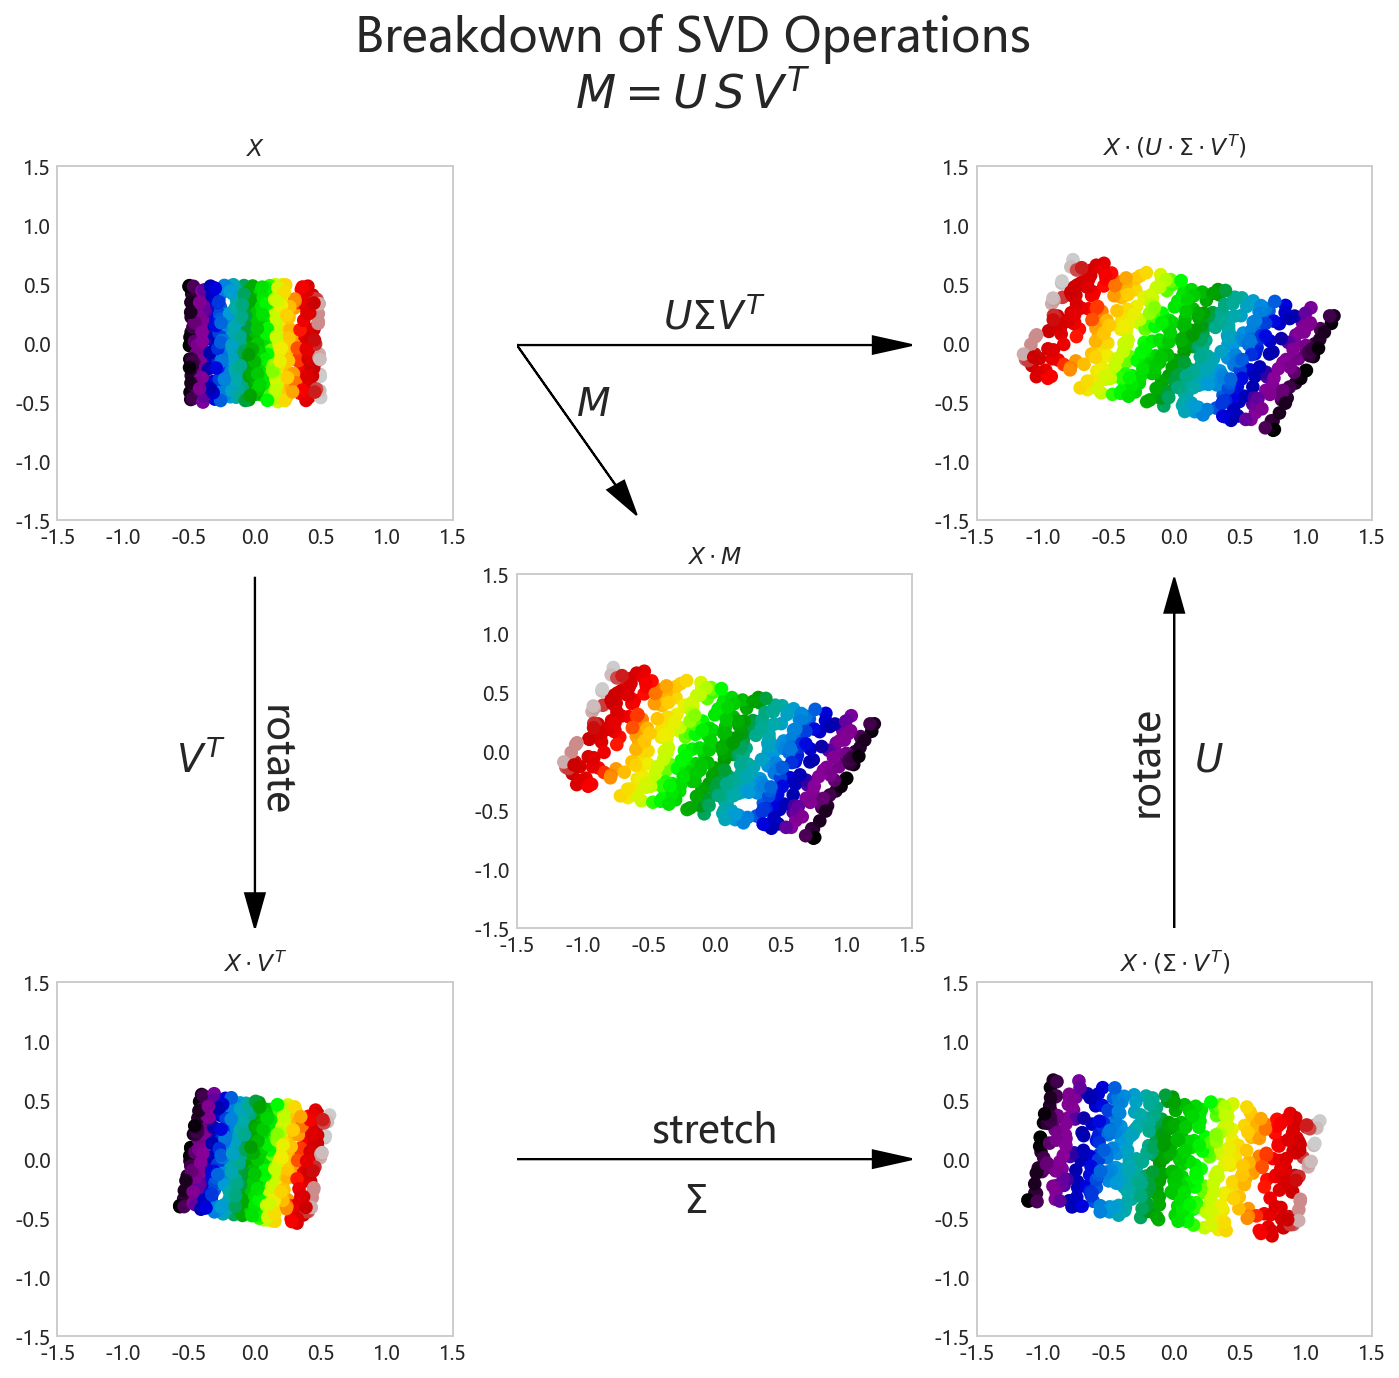

奇异值 = [2.0811 1.0811]
||M - UΣV^T|| = 9.28879225241625e-16
||XM - X(UΣV^T)|| = 5.962494395546412e-15


In [3]:
np.random.seed(123)
n_observations = 500
n_dim = 2
X = np.random.rand(n_observations, n_dim) - 0.5

M = np.array([
    [-2.0,  0.5],
    [-0.5, -1.0],
])

colors = X[:, 0]
cmap = "nipy_spectral"

U, singular_values, Vt = svd(M)
S = np.diag(singular_values)

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
plt.suptitle("Breakdown of SVD Operations\n$M = U\\,S\\,V^T$", fontsize=24, ha="center")

plt.sca(axs[0][0])
plt.scatter(X[:, 0], X[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X$")

XM = X @ M
plt.sca(axs[1][1])
plt.scatter(XM[:, 0], XM[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot M$")

XVt = X @ Vt
plt.sca(axs[2][0])
plt.scatter(XVt[:, 0], XVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot V^T$")

XSVt = X @ (S @ Vt)
plt.sca(axs[2][2])
plt.scatter(XSVt[:, 0], XSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot (\\Sigma \\cdot V^T)$")

XUSVt = X @ (U @ S @ Vt)
plt.sca(axs[0][2])
plt.scatter(XUSVt[:, 0], XUSVt[:, 1], c=colors, cmap=cmap)
plt.xlim([-1.5, 1.5]); plt.ylim([-1.5, 1.5]); plt.grid()
plt.title("$X \\cdot (U \\cdot \\Sigma \\cdot V^T)$")

plt.sca(axs[0][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.arrow(0.0, 0.5, 0.25, -0.4, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.15, 0.3, "$M$", fontsize=20)
plt.text(0.5, 0.55, "$U\\Sigma V^T$", fontsize=20, ha="center")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.sca(axs[1][0])
plt.arrow(0.5, 1.0, 0.0, -0.9, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.3, 0.45, "$V^T$", fontsize=20)
plt.text(0.55, 0.35, "rotate", fontsize=20, ha="center", rotation=-90)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.sca(axs[2][1])
plt.arrow(0.0, 0.5, 0.9, 0.0, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.42, 0.35, "$\\Sigma$", fontsize=20)
plt.text(0.5, 0.55, "stretch", fontsize=20, ha="center")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.0]); plt.axis("off")

plt.sca(axs[1][2])
plt.arrow(0.5, 0.0, 0.0, 0.9, capstyle="round", head_width=0.05, head_length=0.1, fc="black")
plt.text(0.55, 0.45, "$U$", fontsize=20)
plt.text(0.43, 0.35, "rotate", fontsize=20, ha="center", rotation=90)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.01]); plt.axis("off")

plt.tight_layout()
plt.show()

print("奇异值 =", singular_values)
print("||M - UΣV^T|| =", np.linalg.norm(M - U @ S @ Vt))
print("||XM - X(UΣV^T)|| =", np.linalg.norm(XM - XUSVt))

几何上，

$$
V^\top:\ \text{选取输入空间中的主方向}
$$

$$
\Sigma:\ \text{沿标准坐标轴缩放}
$$

$$
U:\ \text{把标准基转到输出空间主方向}
$$

更严格地说，$U$ 与 $V$ 都是正交矩阵（或列正交矩阵），满足

$$
U^\top U = I,
\qquad
V^\top V = I
$$

因此它们保持内积、长度与夹角；真正改变尺度的是 $\Sigma$。这就是为什么奇异值分解能把“方向变化”和“尺度变化”清楚分离。

## 理解二：low-rank 近似

由

$$
A = \sum_{i=1}^{r}\sigma_i u_i v_i^\top
$$

截断得到

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

则 $A_k$ 是最优 rank-$k$ 近似：

$$
A_k = \arg\min_{\operatorname{rank}(B)\le k}\|A-B\|_F
$$

把灰度图像看成矩阵后，截断 SVD 就对应图像压缩。

这里的 low-rank 近似不是经验性的，而是严格最优的。除了 Frobenius 范数外，在谱范数下也成立：

$$
\|A-A_k\|_2 = \sigma_{k+1},
\qquad
\|A-A_k\|_F^2 = \sum_{i>k}\sigma_i^2
$$

因此奇异值衰减越快，截断后的近似越有效；这也是后续张量截断能够成立的数学基础。

image shape = (500, 500)
k    rel_error      parameters
--------------------------------
5   0.201820       5005
20  0.104151       20020
50  0.058932       50050
75  0.041544       75075
100 0.030387       100100


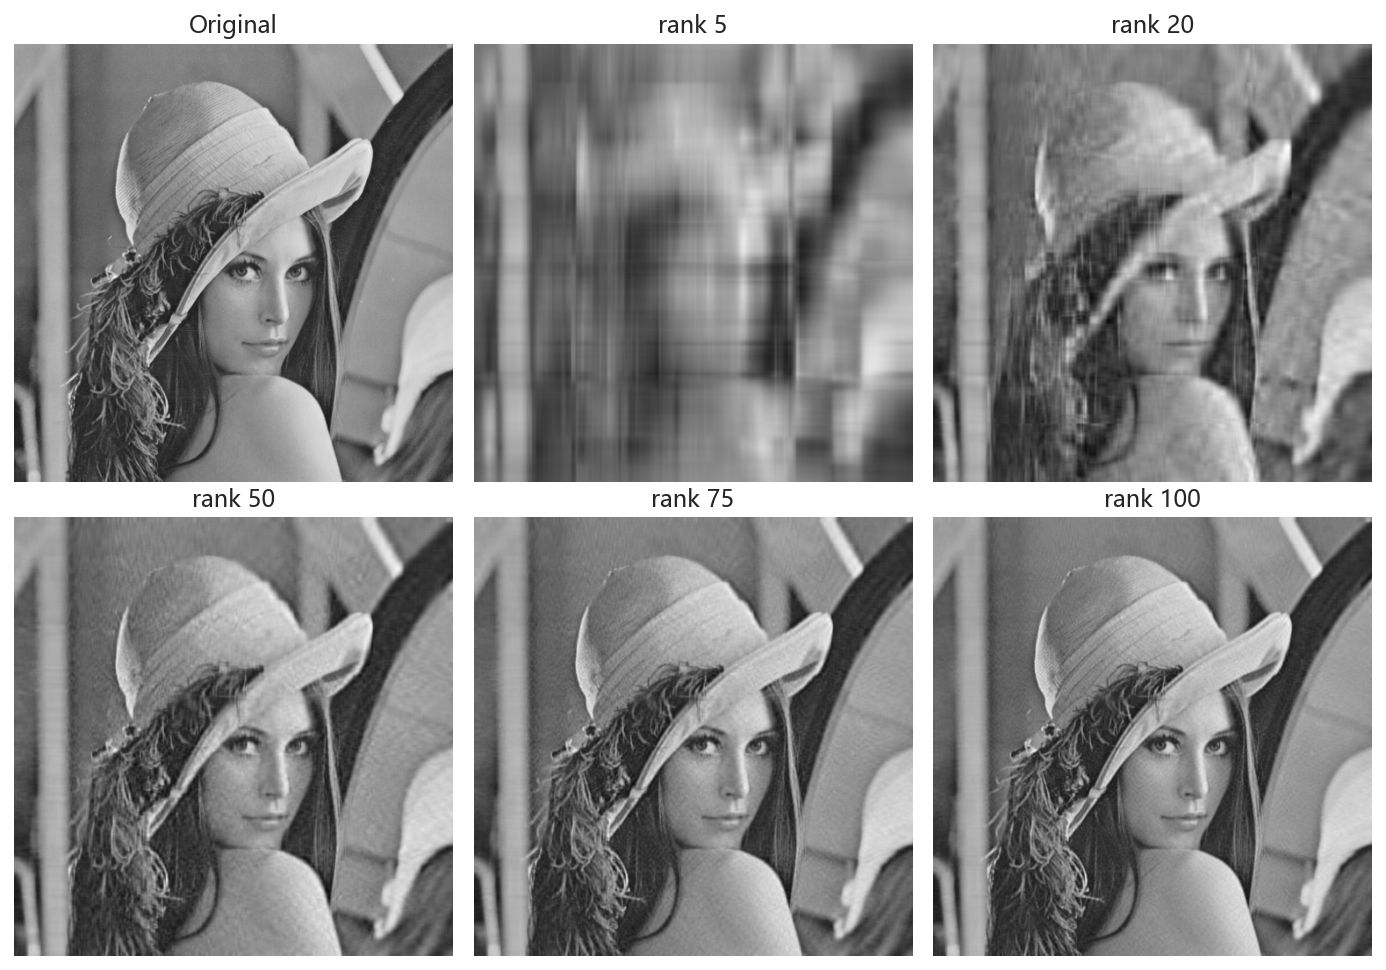

In [4]:
img_path = Path("Lenna.png")
img = np.asarray(Image.open(img_path).convert("L"), dtype=float) / 255.0

U_img, s_img, Vt_img = np.linalg.svd(img, full_matrices=False)

def svd_rank_k(k: int):
    return (U_img[:, :k] * s_img[:k]) @ Vt_img[:k, :]

ks = [5, 20, 50, 75, 100]
m, n = img.shape

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.ravel()

axes[0].imshow(img, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title("Original")
axes[0].axis("off")

print(f"image shape = {img.shape}")
print("k    rel_error      parameters")
print("-" * 32)

for ax, k in zip(axes[1:], ks):
    img_k = svd_rank_k(k)
    rel_error = np.linalg.norm(img - img_k) / np.linalg.norm(img)
    params = m * k + k + k * n
    ax.imshow(img_k, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"rank {k}")
    ax.axis("off")
    print(f"{k:<4}{rel_error:<15.6f}{params}")

plt.tight_layout()
plt.show()

## 小结

$$
A = U\Sigma V^\top
$$

给出几何分解；

$$
A_k = \sum_{i=1}^{k}\sigma_i u_i v_i^\top
$$

给出最优 low-rank 近似。后面的 MPS / TT-SVD，本质上就是不断重复这个思想。

# 量子开放系统课程汇报--张量网络：第二部分
## 指数墙问题、TT与MPS